This is using M4Raw tutorial dataset but the math is self done so this is not an accurate tutorial notebook. This however does show my current understanding of my concepts.

In [4]:
!pip install -q gdown h5py

## Import details
1.  Numpy to access array
2.  h5py to access h5 files
3.  gdown to access data from public drive

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import gdown
import os


In [6]:
gdown.download_folder("https://drive.google.com/drive/folders/1RQT9oqoBd0xsevhyKSCxKiLuoEb2erhB",quiet=False,use_cookies=False)

Retrieving folder contents


Processing file 1rq-tr_rQHoZUbw1QhV9Qty41-cq5ODiy 2022061003_FLAIR01.h5
Processing file 10dLDATcpxnOvn2Hkt13GwDchRKleTMIo 2022061003_FLAIR02.h5
Processing file 1wVDkODzku7oW3Gw1dAS89cpy4KIZALlR 2022061003_T101.h5
Processing file 14dtqQivhiGszCTuYk__K18MOTeVLn9Y2 2022061003_T102.h5
Processing file 1jlmB4MpzhgvWphSQI5yb2ySjc5hhN3K1 2022061003_T103.h5
Processing file 1ZIcXWngJsboiGmVIZUfVBd5VJNXIQyxq 2022061003_T201.h5
Processing file 1a3GHrkeLaqQ6hhEUqUcKhQNexizu0kkx 2022061003_T202.h5
Processing file 1jYlgo2CMcCGGQuZl42rqNLlTpmjUA9lh 2022061003_T203.h5


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1rq-tr_rQHoZUbw1QhV9Qty41-cq5ODiy
To: /content/M4Raw_sample/2022061003_FLAIR01.h5
100%|██████████| 12.6M/12.6M [00:00<00:00, 56.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=10dLDATcpxnOvn2Hkt13GwDchRKleTMIo
To: /content/M4Raw_sample/2022061003_FLAIR02.h5
100%|██████████| 12.6M/12.6M [00:00<00:00, 54.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wVDkODzku7oW3Gw1dAS89cpy4KIZALlR
To: /content/M4Raw_sample/2022061003_T101.h5
100%|██████████| 12.6M/12.6M [00:00<00:00, 51.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=14dtqQivhiGszCTuYk__K18MOTeVLn9Y2
To: /content/M4Raw_sample/2022061003_T102.h5
100%|██████████| 12.6M/12.6M [00:00<00:00, 49.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jlmB4MpzhgvWphSQI5yb2ySjc5hhN3K1
To: /content/M4Raw_sample/2022061003_T103.h5
100%|██████████| 12.6M

['/content/M4Raw_sample/2022061003_FLAIR01.h5',
 '/content/M4Raw_sample/2022061003_FLAIR02.h5',
 '/content/M4Raw_sample/2022061003_T101.h5',
 '/content/M4Raw_sample/2022061003_T102.h5',
 '/content/M4Raw_sample/2022061003_T103.h5',
 '/content/M4Raw_sample/2022061003_T201.h5',
 '/content/M4Raw_sample/2022061003_T202.h5',
 '/content/M4Raw_sample/2022061003_T203.h5']

We access the data to see the image weightage method

In [7]:
h5_files=[]
location=r'/content/M4Raw_sample'
for root, _, files in os.walk(location):
  for file in files:
    if file.endswith(".h5"):
      h5_files.append(os.path.join(root,file))
for file in sorted(h5_files):
  print(file)

/content/M4Raw_sample/2022061003_FLAIR01.h5
/content/M4Raw_sample/2022061003_FLAIR02.h5
/content/M4Raw_sample/2022061003_T101.h5
/content/M4Raw_sample/2022061003_T102.h5
/content/M4Raw_sample/2022061003_T103.h5
/content/M4Raw_sample/2022061003_T201.h5
/content/M4Raw_sample/2022061003_T202.h5
/content/M4Raw_sample/2022061003_T203.h5


## shape
The K space here has 4 dim. It is because it is arranged (slices, coils or channels, kx , ky)
Because it has magnitude and phase info(which is imaginary) the dtype is complex64.


In [8]:
fname=sorted(h5_files)[0]
print(fname)

with h5py.File(fname,"r") as hf:
  print("keys:",list(hf.keys()))
  for k in hf.keys():
    print(f"{k}:shape={hf[k].shape},dtype={hf[k].dtype}")
  print("attrs:", dict(hf.attrs))
  kspace=hf["kspace"][()]
  rss_gt=hf["reconstruction_rss"][()]

print("\nkspace:", kspace.shape, kspace.dtype)
print("rss_gt:", rss_gt.shape)

/content/M4Raw_sample/2022061003_FLAIR01.h5
keys: ['ismrmrd_header', 'kspace', 'reconstruction_rss']
ismrmrd_header:shape=(),dtype=object
kspace:shape=(18, 4, 256, 256),dtype=complex64
reconstruction_rss:shape=(18, 256, 256),dtype=float32
attrs: {'acquisition': 'AXFLAIR', 'max': np.float64(115.29900007154666), 'patient_id': '88448eec274d9248d1a2487a8548ee41'}

kspace: (18, 4, 256, 256) complex64
rss_gt: (18, 256, 256)


In [9]:
slice_idx=5
slice_kspace=kspace[slice_idx]
print(slice_kspace.shape,slice_kspace.dtype)

(4, 256, 256) complex64


1.  Random black dots- data dropouts/packet loss
2.  (if) middle black strips- undersampling/masking to train models
3.  Edge strips black- Oversampling truncation or zero padding to prevent aliasing(wrap around)

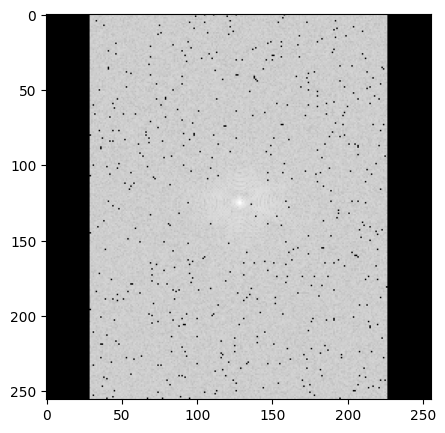

In [10]:
plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(slice_kspace[0])+1e-9),cmap="gray")
plt.show()

We will take individual K space for each coil (we have 4 coils) and apply inverse fast fourier transform to it

We do the shifting to bring the centre on the corners because inverse fourier transform expects it to be at [0,0] position.

Then we do the ifft math (see notes for math) once we have the matrix we shift it again and this converts it from k space to spatial space

coil images: (4, 256, 256) complex64


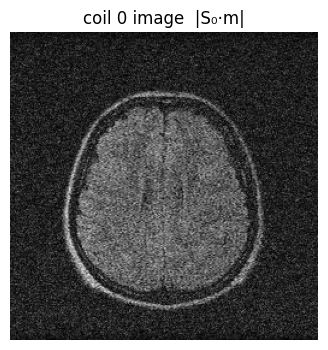

In [11]:
def ifft2c(kspace):
  axes=(-2,-1)
  return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace,axes=axes),axes=axes,norm="ortho"),axes=axes,)

coil_images=ifft2c(slice_kspace)

print("coil images:", coil_images.shape, coil_images.dtype)
plt.figure(figsize=(4,4))
plt.imshow(np.abs(coil_images[0]), cmap="gray")
plt.title("coil 0 image  |S₀·m|")
plt.axis("off"); plt.show()

RSS combines multi coil view to give a clearer image and reduces noise overall

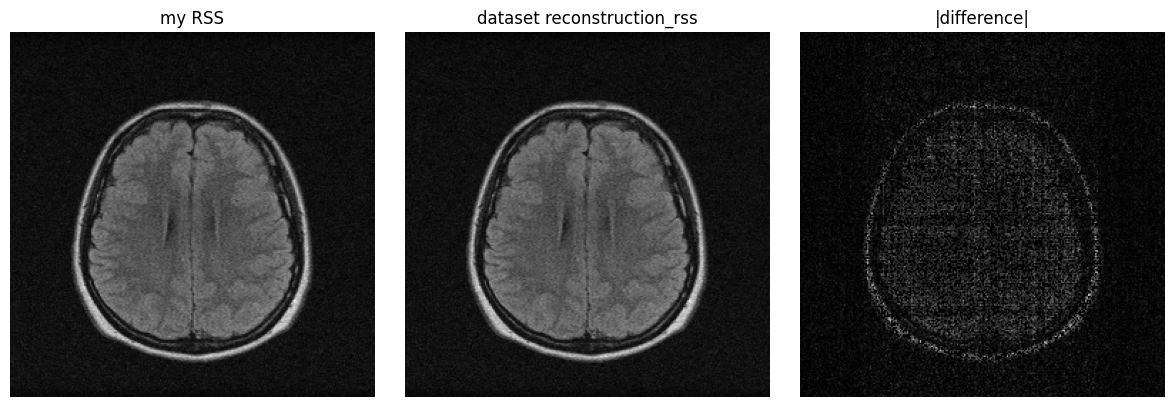

max abs difference: 2.2888184e-05


In [12]:
def rss(coil_imgs):
  return np.sqrt(np.sum(np.abs(coil_imgs)**2,axis =0))

my_rss=rss(coil_images)
ref=rss_gt[slice_idx]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(my_rss, cmap="gray");          ax[0].set_title("my RSS")
ax[1].imshow(ref,    cmap="gray");          ax[1].set_title("dataset reconstruction_rss")
ax[2].imshow(np.abs(my_rss - ref), cmap="gray"); ax[2].set_title("|difference|")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print("max abs difference:", np.max(np.abs(my_rss - ref)))

To estimate coil sensitivity we build a hanning filter matrix first.
The calib size has to be less than no of ACS lines.
The 1d hanning window is then converted in 2d by multiplyuing the window to its transpose.
 Then we do padding around it of 0
 then we multiply it with our coil k space for each coil.

We do reconstruction of this k space.
Find root sum square and then divide the reconstructed images with the rss to get the css map.


Even though RSS gave us a pretty decent image but because we use accelerated MRI meaning skipping lines it can give us a overlapping/folded image  and have uneven brightness.
If the image is folded (aliasing) a post- fourier transform image will show the front of the brain wrapped over the back of the brain.
Additionally,  In a multi-coil setup, a brain image combined purely by RSS will often look bright on the outer edges (near the coils) and dark/shaded in the very center.



csm: (4, 256, 256) complex128


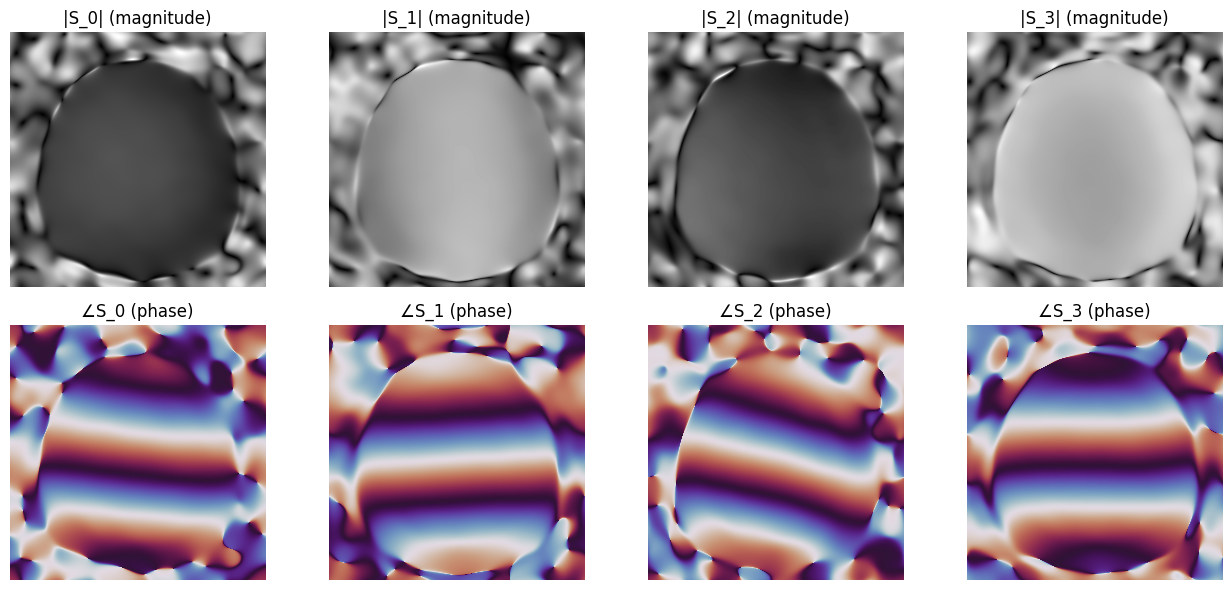

In [13]:
def estimate_csm(slice_kspace,calib_size=24):
  nc,ny,nx=slice_kspace.shape
  cy,cx=ny//2,nx//2
  half=calib_size//2

  win2d=np.outer(np.hanning(calib_size),np.hanning(calib_size))
  window=np.zeros((ny,nx))
  window[cy-half:cy+half,cx-half:cx+half]=win2d

  low_k=slice_kspace*window[None]
  low_imgs=ifft2c(low_k)

  rss_low  = np.sqrt(np.sum(np.abs(low_imgs)**2, axis=0)) + 1e-12
  csm = low_imgs / rss_low[None]
  return csm, window

csm, window = estimate_csm(slice_kspace, calib_size=24)
print("csm:", csm.shape, csm.dtype)

# look at the magnitude and phase of each coil's sensitivity
fig, ax = plt.subplots(2, 4, figsize=(13, 6))
for i in range(4):
    ax[0, i].imshow(np.abs(csm[i]),   cmap="gray"); ax[0, i].set_title(f"|S_{i}| (magnitude)")
    ax[1, i].imshow(np.angle(csm[i]), cmap="twilight"); ax[1, i].set_title(f"∠S_{i} (phase)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

This subtle bending and shifting is the coil-specific phase fingerprint. Because your 4 coils are positioned at different physical coordinates around the patient's head, the electromagnetic wave travels a slightly different path length to reach each coil loop.

Initiate a mask with alternating true values and then multiply it to K space of all 4 coils of our subject and then generate a reconstructed image

kept 128 of 256 lines  (R=2)


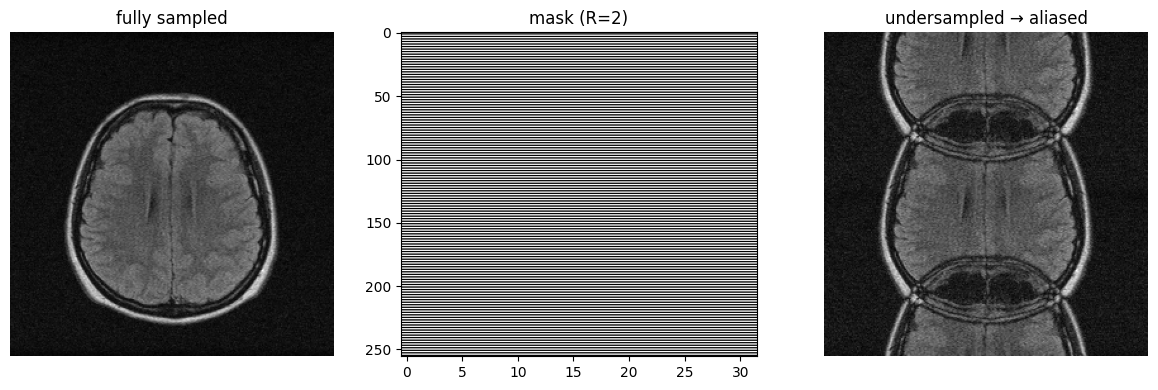

In [14]:
def make_mask(ny, R=2, num_acs=0):
    """Every R-th k_y line, PLUS a fully-sampled center block of num_acs lines."""
    mask = np.zeros(ny, dtype=bool)
    mask[::R] = True                                   # uniform undersampling
    if num_acs > 0:
        c = ny // 2
        mask[c - num_acs//2 : c + num_acs//2] = True
    return mask

R=2
mask=make_mask(slice_kspace.shape[1],R=R,num_acs=0)
print(f"kept {mask.sum()} of {len(mask)} lines  (R={R})")

masked_kspace = slice_kspace * mask[None, :, None]

aliased_coils=ifft2c(masked_kspace)
aliased_rss=rss(aliased_coils)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rss(ifft2c(slice_kspace)), cmap="gray"); ax[0].set_title("fully sampled")
ax[1].imshow(np.abs(mask[:, None] * np.ones((1, 32))), cmap="gray", aspect="auto"); ax[1].set_title(f"mask (R={R})")
ax[2].imshow(aliased_rss, cmap="gray"); ax[2].set_title("undersampled → aliased")
for a in (ax[0], ax[2]): a.axis("off")
plt.tight_layout(); plt.show()


We find the overlapping rows, example:

 $y_1 = 10 + 0 \times 128 = 10$

 $y_2 = 10 + 1 \times 128 = 138$

 and then we find the matrix S which tells us how well are the coils seeing those two positions.

 collects the 4 complex numbers measured by your 4 coils at the folded pixel, we multiply by R to bring the brightness back up because undersampling has also dropped the total energy of image.

Then we solve  the linear system $\mathbf{S}\boldsymbol{\rho} = \mathbf{b}$ using a least-squares pseudo-inverse. Because we have 4 equations (coils) and only 2 unknowns ($\rho_1$ and $\rho_2$), the system is overdetermined.

After solving we write the data back

In [15]:
# brain support from the clean fully-sampled image
support = rss(ifft2c(slice_kspace))
brain   = support > 0.08 * support.max()        # tune threshold if it clips/leaks
csm_masked = csm * brain[None]                  # zero the noisy background maps

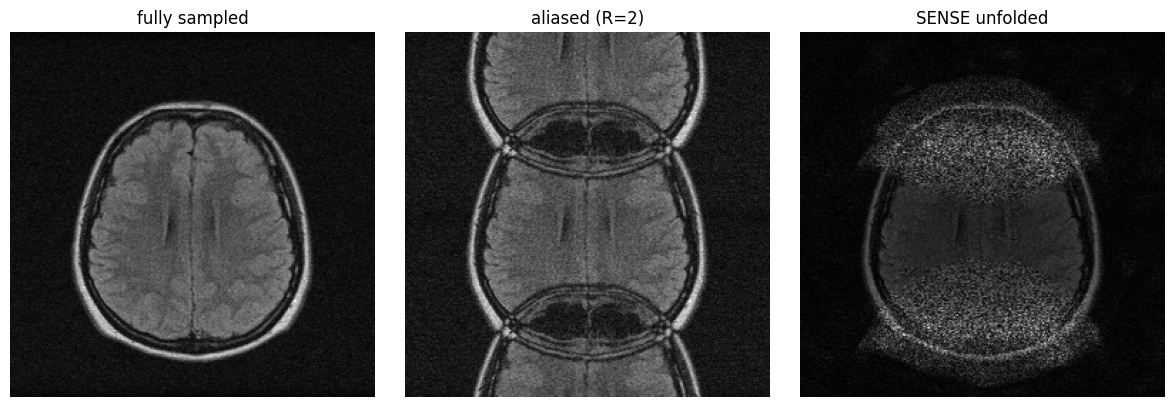

In [16]:
def sense_recon(slice_kspace,csm,R=2):
  nc, ny, nx = slice_kspace.shape
  mask    = make_mask(ny, R=R, num_acs=0)
  aliased=ifft2c(slice_kspace*mask[None,:,None])
  recon_img=np.zeros((ny,nx),dtype=np.complex128)
  step = ny//R
  for y in range(step):
    for x in range(nx):
      ys = [(y + a*step) % ny for a in range(R)]
      S  = csm[:, ys, x]
      b = aliased[:, y, x] * R
      rho, *_ = np.linalg.lstsq(S, b, rcond=1e-2)
      recon_img[ys, x] = rho
  return np.abs(recon_img)
sense_img = sense_recon(slice_kspace, csm, R=2)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rss(ifft2c(slice_kspace)), cmap="gray"); ax[0].set_title("fully sampled")
ax[1].imshow(rss(ifft2c(slice_kspace*make_mask(256,2)[None,:,None])), cmap="gray"); ax[1].set_title("aliased (R=2)")
ax[2].imshow(sense_img, cmap="gray"); ax[2].set_title("SENSE unfolded")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

(SᴴS + λI)⁻¹ Sᴴb  — λ damps the noise-amplifying directions

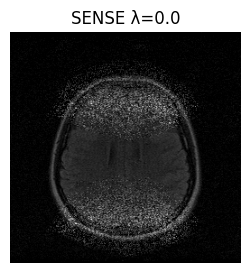

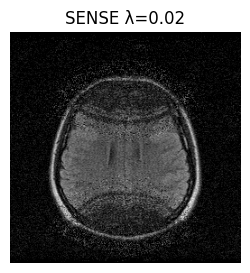

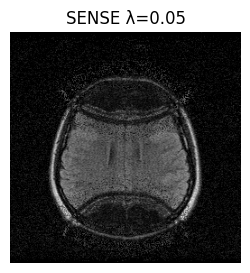

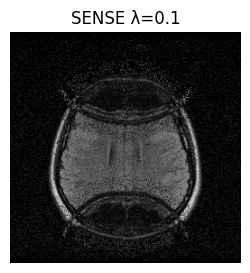

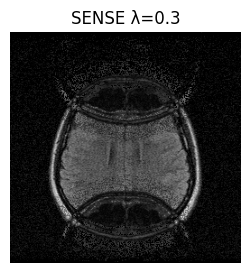

In [17]:
def sense_recon_reg(slice_kspace, csm, R=2, lam=0.05):
    nc, ny, nx = slice_kspace.shape
    aliased = ifft2c(slice_kspace * make_mask(ny, R=R, num_acs=0)[None, :, None])
    recon = np.zeros((ny, nx), dtype=np.complex128)
    step = ny // R
    for y in range(step):
        for x in range(nx):
            ys  = [(y + a*step) % ny for a in range(R)]
            S   = csm[:, ys, x]                     # (nc x R)
            b   = aliased[:, y, x] * R
            StS = S.conj().T @ S                    # (R x R)
            # (SᴴS + λI)⁻¹ Sᴴb  — λ damps the noise-amplifying directions
            rho = np.linalg.lstsq(StS + lam*np.eye(R), S.conj().T @ b, rcond=None)[0]
            recon[ys, x] = rho
    return np.abs(recon)

# tune lam by eye: 0 = your speckled result, higher = smoother but softer
for lam in [0.0, 0.02, 0.05, 0.1, 0.3]:
    img = sense_recon_reg(slice_kspace, csm_masked, R=2, lam=lam)
    plt.figure(figsize=(3,3)); plt.imshow(img, cmap="gray")
    plt.title(f"SENSE λ={lam}"); plt.axis("off"); plt.show()

he middle panel is the folded brain; the right panel is the brain unfolded

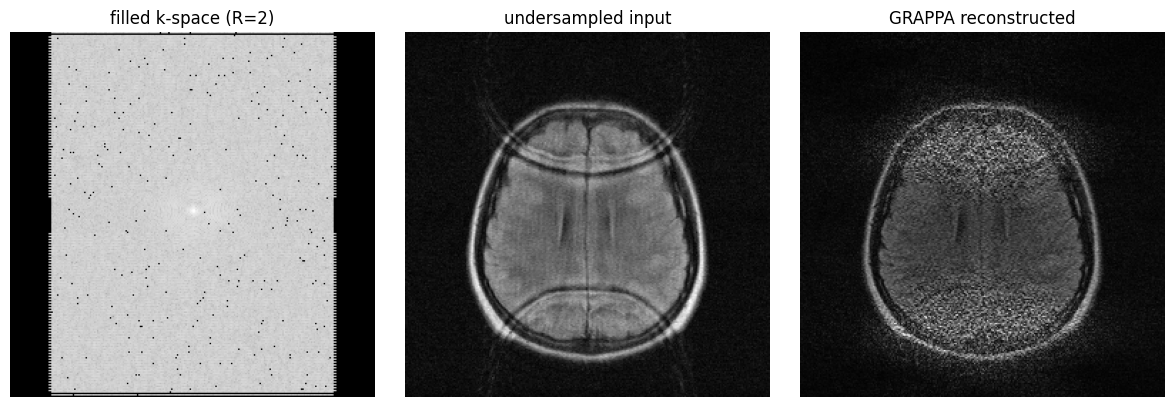

In [18]:
R_factor = 2
def grappa_recon(slice_kspace, R=2, num_acs=24, kx_w=5):
    nc, ny, nx = slice_kspace.shape
    mask = make_mask(ny, R=R, num_acs=num_acs)
    ks   = slice_kspace * mask[None, :, None]
    kxh  = kx_w // 2
    ksp  = np.pad(ks, ((0,0),(0,0),(kxh,kxh)))
    c    = ny//2; lo, hi = c-num_acs//2, c+num_acs//2

    def gather(arr, y, off, xp):
        return [arr[i, y+o, xp+dx] for o in off for dx in range(-kxh, kxh+1) for i in range(nc)]

    out = ksp.copy()
    for p in range(1, R):                          # one weight set per position in the gap
        off = np.array([-R-p, -p, R-p, 2*R-p])     # 4 sampled source lines — always multiples of R away
        src, tgt = [], []
        for y in range(lo, hi):                    # learn from ACS, this gap-position only
            if y % R != p % R: continue
            if any(not (lo <= y+o < hi) for o in off): continue
            for x in range(nx):
                src.append(gather(ksp, y, off, x+kxh))
                tgt.append([ksp[i, y, x+kxh] for i in range(nc)])
        if not src: continue
        W, *_ = np.linalg.lstsq(np.array(src), np.array(tgt), rcond=None)
        for y in range(ny):                        # apply to fill this gap-position everywhere
            if mask[y] or y % R != p % R: continue
            if any(not (0 <= y+o < ny) for o in off): continue
            for x in range(nx):
                out[:, y, x+kxh] = np.array(gather(out, y, off, x+kxh)) @ W
    out = out[:, :, kxh:kxh+nx]
    return rss(ifft2c(out)), out


grappa_img, grappa_kspace = grappa_recon(slice_kspace, R=R_factor, num_acs=24)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.log(np.abs(grappa_kspace[0])+1e-9), cmap="gray")
ax[0].set_title(f"filled k-space (R={R_factor})")

# FIX: Changed the hardcoded 2 to R_factor so the plot updates dynamically!
ax[1].imshow(rss(ifft2c(slice_kspace*make_mask(256,R_factor,24)[None,:,None])), cmap="gray")
ax[1].set_title("undersampled input")

ax[2].imshow(grappa_img, cmap="gray")
ax[2].set_title("GRAPPA reconstructed")

for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

In [19]:
import numpy as np
m   = make_mask(256, 2, 24)
und_k = slice_kspace * m[None, :, None]

g_img, g_k = grappa_recon(slice_kspace, R=2, num_acs=24)     # fresh call, R=2
und_img    = rss(ifft2c(und_k))

# 1) did GRAPPA change anything at all vs the aliased input?
print("1) grappa-vs-input rel diff :", np.linalg.norm(g_img - und_img) / np.linalg.norm(und_img))

# 2) did the missing k-space lines actually get filled?
miss = ~m
print("2) missing-row |k|  input=0 |",
      "filled =", f"{np.abs(g_k[:, miss]).mean():.3e}",
      " true =", f"{np.abs(slice_kspace[:, miss]).mean():.3e}")

# 3) is DC at the center, so the ACS block sees real signal?
mag = np.abs(slice_kspace).sum(0)
print("3) k-space peak at (row,col) =", np.unravel_index(mag.argmax(), mag.shape), " (want ~128,128)")

# 4) is the mask what we think — every-other line plus a 24-line center?
print("4) mask kept", m.sum(), "lines; center block rows:", np.where(m[116:140])[0] + 116)

1) grappa-vs-input rel diff : 0.45831925
2) missing-row |k|  input=0 | filled = 9.379e+00  true = 4.143e+00
3) k-space peak at (row,col) = (np.int64(125), np.int64(128))  (want ~128,128)
4) mask kept 140 lines; center block rows: [116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139]


fold strength (||aliased-full||/||full||): 0.6383306
median |csm| INSIDE brain: 0.43805973220624994
SENSE/ref brightness ratio: 1.298302025882759


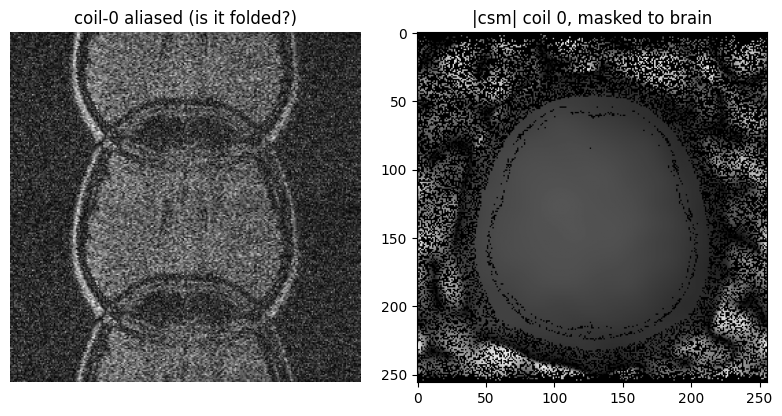

<Figure size 640x480 with 0 Axes>

In [20]:
full    = rss(ifft2c(slice_kspace))
aliased = rss(ifft2c(slice_kspace * make_mask(256, 2)[None,:,None]))
print("fold strength (||aliased-full||/||full||):", np.linalg.norm(aliased-full)/np.linalg.norm(full))
print("median |csm| INSIDE brain:", np.median(np.abs(csm)[:, support>0.2*support.max()]))
print("SENSE/ref brightness ratio:", np.median(sense_img[brain]) / np.median(full[brain]))

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(np.abs(ifft2c(slice_kspace*make_mask(256,2)[None,:,None])[0]), cmap="gray"); ax[0].set_title("coil-0 aliased (is it folded?)")
ax[1].imshow(np.abs(csm[0])*brain, cmap="gray"); ax[1].set_title("|csm| coil 0, masked to brain")
for a in ax: a.axis("off"); plt.tight_layout(); plt.show()

In [21]:
ref = rss(ifft2c(slice_kspace))
print("GRAPPA R=2 relative error:", np.linalg.norm(grappa_img - ref) / np.linalg.norm(ref))

GRAPPA R=2 relative error: 0.43197924
